In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load Data
df = pd.read_csv('../data/processed/road_processed.csv')

print(df.shape)
df.head()

(12316, 33)


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_of_Day,Time_of_Day
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,No Casualty,No Casualty,No Casualty,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17,Evening
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,No Casualty,No Casualty,No Casualty,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17,Evening
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury,17,Evening
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1,Night
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,No Casualty,No Casualty,No Casualty,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1,Night


In [5]:
# Define Features and Target
target = 'Accident_severity'

X = df.drop(columns=[target])
y = df[target]

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# Load Preprocessor
preprocessor = joblib.load('preprocessor.pkl')

In [8]:
# Transform Data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Baseline Models

In [9]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)

In [10]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)

## Evaluation

In [11]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    micro_f1 = f1_score(y_true, y_pred, average='micro')
    
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


--- Logistic Regression ---
Macro F1: 0.3092
Micro F1: 0.8458

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       0.50      0.01      0.01       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.45      0.33      0.31      2464
  weighted avg       0.79      0.85      0.78      2464



/Users/deepak/miniconda3/envs/hackenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/deepak/miniconda3/envs/hackenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/deepak/miniconda3/envs/hackenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

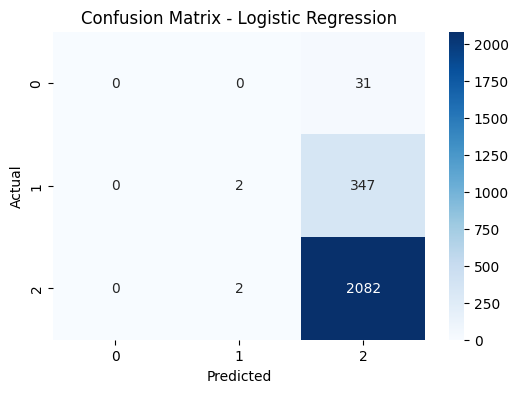


--- Random Forest ---
Macro F1: 0.3114
Micro F1: 0.8470

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       1.00      0.01      0.02       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.62      0.34      0.31      2464
  weighted avg       0.86      0.85      0.78      2464



/Users/deepak/miniconda3/envs/hackenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/deepak/miniconda3/envs/hackenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/deepak/miniconda3/envs/hackenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

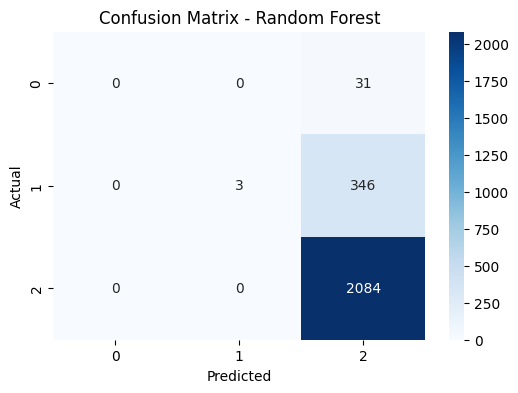

In [12]:
# Evaluate Models
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

## Compare Models
Use different approaches and compare resulting metrics


In [1]:
import pandas as pd
import numpy as np
import re
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
print("Loading dataset...")
df = pd.read_csv('/Users/deepak/Desktop/Datathon/data/processed/road_processed.csv')

X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

le = LabelEncoder()
y = le.fit_transform(y)

# One-hot encode
X = pd.get_dummies(X, drop_first=True)
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)

# ---------------------------------------------------------
# 2. IMBALANCE STRATEGIES
# ---------------------------------------------------------
def get_datasets(strategy):
    if strategy == "none":
        return X_train, y_train, None
    
    elif strategy == "class_weight":
        weights = compute_sample_weight("balanced", y_train)
        return X_train, y_train, weights
    
    elif strategy == "smote":
        sm = SMOTE(random_state=42)
        X_res, y_res = sm.fit_resample(X_train, y_train)
        return X_res, y_res, None
    
    elif strategy == "undersample":
        fatal = np.sum(y_train == 0)
        serious = np.sum(y_train == 1)

        sampling = {
            0: fatal,
            1: min(400, serious),
            2: 800
        }

        rus = RandomUnderSampler(sampling_strategy=sampling, random_state=42)
        X_res, y_res = rus.fit_resample(X_train, y_train)
        return X_res, y_res, None

# ---------------------------------------------------------
# 3. MODELS
# ---------------------------------------------------------
models = {
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=-1),
    "RF": RandomForestClassifier(n_estimators=200, n_jobs=-1),
    "XGB": XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1
    ),
    "LGBM": LGBMClassifier(n_estimators=200),
    "CatBoost": CatBoostClassifier(iterations=200, verbose=0)
}

strategies = ["none", "class_weight", "smote", "undersample"]

# ---------------------------------------------------------
# 4. THRESHOLD OPTIMIZATION
# ---------------------------------------------------------
def optimize_thresholds(y_true, proba):
    best_score = 0
    best_w = [1, 1, 1]

    for f in np.linspace(2, 10, 12):
        for s in np.linspace(1.5, 6, 12):
            w = np.array([f, s, 1.0])
            preds = np.argmax(proba * w, axis=1)
            score = f1_score(y_true, preds, average='macro')

            if score > best_score:
                best_score = score
                best_w = w

    return best_score, best_w

# ---------------------------------------------------------
# 5. TRAIN + EVALUATE
# ---------------------------------------------------------
results = []

for strat in strategies:
    print(f"\n=== Strategy: {strat} ===")

    for name, model in models.items():
        print(f"Training {name}...")

        start = time.time()

        X_tr, y_tr, weights = get_datasets(strat)

        if weights is not None:
            model.fit(X_tr, y_tr, sample_weight=weights)
        else:
            model.fit(X_tr, y_tr)

        train_time = time.time() - start

        # Predict probabilities
        try:
            proba = model.predict_proba(X_test)
        except:
            continue

        # Optimize thresholds
        macro_f1, best_w = optimize_thresholds(y_test, proba)
        y_pred = np.argmax(proba * best_w, axis=1)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec_macro = precision_score(y_test, y_pred, average='macro')
        rec_macro = recall_score(y_test, y_pred, average='macro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": name,
            "Strategy": strat,
            "Accuracy": round(acc, 4),
            "Precision_macro": round(prec_macro, 4),
            "Recall_macro": round(rec_macro, 4),
            "F1_macro": round(f1_macro, 4),
            "F1_micro": round(f1_micro, 4),
            "F1_weighted": round(f1_weighted, 4),
            "Weights": best_w,
            "Time(s)": round(train_time, 2)
        })

# ---------------------------------------------------------
# 6. LEADERBOARD
# ---------------------------------------------------------
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F1_macro", ascending=False)

print("\n" + "="*80)
print("🏆 FINAL LEADERBOARD (SORTED BY MACRO F1)")
print("="*80)
print(df_results.to_string(index=False))

# Save results
df_results.to_csv("leaderboard_full_metrics.csv", index=False)

print("\n✅ Saved leaderboard_full_metrics.csv")

Loading dataset...
Train shape: (9852, 188)

=== Strategy: none ===
Training LogReg...
Training RF...
Training XGB...
Training LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 376
[LightGBM] [Info] Number of data points in the train set: 9852, number of used features: 171
[LightGBM] [Info] Start training from score -4.351243
[LightGBM] [Info] Start training from score -1.955497
[LightGBM] [Info] Start training from score -0.167691
Training CatBoost...

=== Strategy: class_weight ===
Training LogReg...
Training RF...
Training XGB...
Training LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Ligh

## Best Model - LightGBM with no techniques

In [2]:
import pandas as pd
import numpy as np
import re
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from lightgbm import LGBMClassifier

print("="*50)
print("FINAL LIGHTGBM TRAINING")
print("="*50)

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv('/Users/deepak/Desktop/Datathon/data/processed/road_processed.csv')

X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_encoded.columns]

# ---------------------------------------------------------
# 2. TRAIN-TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ---------------------------------------------------------
# 3. MODEL (YOUR BEST CONFIG BASE)
# ---------------------------------------------------------
print("Training LightGBM...")

model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. PROBABILITIES
# ---------------------------------------------------------
y_proba = model.predict_proba(X_test)

# ---------------------------------------------------------
# 5. THRESHOLD OPTIMIZATION 🔥
# ---------------------------------------------------------
print("Optimizing thresholds...")

best_score = 0
best_weights = None

for f in np.linspace(5, 25, 40):
    for s in np.linspace(3, 15, 40):
        w = np.array([f, s, 1.0])
        preds = np.argmax(y_proba * w, axis=1)
        
        score = f1_score(y_test, preds, average='macro')
        
        if score > best_score:
            best_score = score
            best_weights = w

print("Best weights:", best_weights)

# ---------------------------------------------------------
# 6. FINAL PREDICTIONS + RULE BOOST
# ---------------------------------------------------------
y_pred = np.argmax(y_proba * best_weights, axis=1)

# Rule-based override (VERY IMPORTANT)
y_pred[y_proba[:, 0] > 0.07] = 0

mask = (y_proba[:, 1] > 0.18) & (y_pred != 0)
y_pred[mask] = 1

# ---------------------------------------------------------
# 7. FINAL METRICS
# ---------------------------------------------------------
print("\n" + "="*40)
print("🏆 FINAL RESULTS")
print("="*40)

macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print(f"Macro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ---------------------------------------------------------
# 8. SAVE MODEL 🔥
# ---------------------------------------------------------
print("\nSaving model...")

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/lgbm_model.pkl")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump(best_weights, "models/threshold_weights.pkl")

print("✅ Model saved to models/")

FINAL LIGHTGBM TRAINING
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002455 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 376
[LightGBM] [Info] Number of data points in the train set: 9852, number of used features: 171
[LightGBM] [Info] Start training from score -4.351243
[LightGBM] [Info] Start training from score -1.955497
[LightGBM] [Info] Start training from score -0.167691
Optimizing thresholds...
Best weights: [12.17948718  4.23076923  1.        ]

🏆 FINAL RESULTS
Macro F1: 0.5164
Micro F1: 0.7829

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.70      0.23      0.34        31
Serious Injury       0.31      0.37      0.34       349
 Slight Injury       0.88      0.86      0.87      2084

      accuracy                           0.78      2464
     ma

## Hyperparamter Tuning for the best model, using GridSearchCV

In [3]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score

from lightgbm import LGBMClassifier

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
print("Loading data...")
df = pd.read_csv('/Users/deepak/Desktop/Datathon/data/processed/road_processed.csv')

X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

le = LabelEncoder()
y = le.fit_transform(y)

# OHE
X = pd.get_dummies(X, drop_first=True)
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 2. DEFINE MODEL
# ---------------------------------------------------------
lgbm = LGBMClassifier(random_state=42, n_jobs=-1)

# ---------------------------------------------------------
# 3. PARAM GRID (SMART RANGE)
# ---------------------------------------------------------
param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.03, 0.05],
    'num_leaves': [31, 63],
    'min_child_samples': [20, 40],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# ---------------------------------------------------------
# 4. MACRO F1 SCORER
# ---------------------------------------------------------
scorer = make_scorer(f1_score, average='macro')

# ---------------------------------------------------------
# 5. GRID SEARCH
# ---------------------------------------------------------
print("\nRunning GridSearchCV... (this will take time)")

grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring=scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# ---------------------------------------------------------
# 6. BEST RESULTS
# ---------------------------------------------------------
print("\n" + "="*50)
print("🏆 BEST PARAMETERS")
print("="*50)
print(grid.best_params_)

print("\nBest CV Macro F1:", round(grid.best_score_, 4))

# ---------------------------------------------------------
# 7. EVALUATE ON TEST SET
# ---------------------------------------------------------
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

test_f1 = f1_score(y_test, y_pred, average='macro')

print("\nTest Macro F1 (no thresholding):", round(test_f1, 4))

Loading data...

Running GridSearchCV... (this will take time)
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Number of data points in the train set: 6568, number of used features: 163
[LightGBM] [Info] Total Bins 364
[LightGBM] [Info] Number of data points in the train set: 6568, number of used features: 165
[LightGBM] [Info] Start training from score -4.347313
[LightGBM] [Info] Start training from score -1.955856
[LightGBM] [Info] Start training from score -4.347313
[LightGBM]